# Airplane Boarding as TAP

# 1. Aircraft Model

The aircraft considered in this project is based on the Boeing 777-300ER operated by Air India.

The objective is to model the boarding process as a transportation network in which passengers move from the boarding gate to their assigned seats while interacting through shared aisle infrastructure.

## Aircraft Layout

The cabin layout used in this project is shown below.

![Boeing 777-300ER Cabin Layout](boeing777.png)

According to Air India specifications, the aircraft contains three travel classes:

| Class | Number of Seats | Seat Configuration |
|---------|---------|---------|
| First Class | 4 | 1-2-1 |
| Business Class | 35 | 2-3-2 |
| Economy Class | 305 | 3-3-3 |

The total aircraft capacity is therefore **344 passengers** (4 + 35 + 305 = 344)


## Cabin Characteristics

The Boeing 777-300ER is a wide-body aircraft equipped with two parallel aisles running through the cabin.

The seating configuration varies across travel classes:

### First Class

Configuration:

    A | DE | K

- 4 seats in total
- 1-2-1 layout
- Direct aisle access for every passenger

### Business Class

Configuration:

    AB | DEF | JK

- 35 seats in total
- 2-3-2 layout
- Two shared aisles

### Economy Class

Configuration:

    ABC | DEF | GHK

- 305 seats in total
- 3-3-3 layout
- Highest passenger density
- Main source of aisle congestion during boarding

## Network Representation

The aircraft cabin is represented as a transportation network.

### Nodes

Nodes represent:

- the boarding gate,
- aisle positions,
- passenger seat locations.

### Links

Links represent:

- movements along the left aisle,
- movements along the right aisle,
- access from an aisle position to a seat.

The two aisles constitute the main transportation infrastructure of the system and are shared by all passengers.

As boarding progresses, interactions between passengers generate congestion on these aisle links.

## Passenger Representation

Each passenger is characterized by:

- a passenger ID,
- a travel class,
- a seat assignment,
- a seat type (window, middle, or aisle).

The seat assignment is fixed and known in advance.

Consequently, passengers do not choose their destination. Their behavior is entirely determined by the boarding strategy under consideration.

## Modeling Assumptions

To keep the model tractable while preserving the key mechanisms of airplane boarding, the following assumptions are adopted:

1. Each passenger has a fixed assigned seat.
2. All passengers walk at the same average speed.
3. Each passenger carries hand luggage requiring storage time.
4. Congestion occurs only in the aircraft aisles.
5. Additional delays may be generated by seat interference during seat access.
6. Passengers do not change seats after entering the aircraft.
7. Boarding strategies only affect the order in which passengers enter the aircraft.

Under these assumptions, airplane boarding can be modeled as a congestion problem on a transportation network and analyzed using traffic assignment concepts.

# 2. Passenger Generation

In order to simulate the boarding process, each seat of the aircraft is associated with a passenger.

Each passenger is characterized by:

- a unique passenger ID,
- a travel class,
- a row number,
- a seat letter,
- a seat type.

Seat types are classified as:

- Window
- Middle
- Aisle

The passenger dataset generated in this section will be used throughout the project to model passenger movements, boarding strategies, and congestion effects.

In [1]:
import pandas as pd

# ============================================================
# Generate passenger population
# ============================================================

passengers = []

pid = 1

# First Class
for _ in range(4):
    passengers.append([pid, "First"])
    pid += 1

# Business Class
for _ in range(35):
    passengers.append([pid, "Business"])
    pid += 1

# Economy Class
for _ in range(305):
    passengers.append([pid, "Economy"])
    pid += 1

# Create dataframe
df_passengers = pd.DataFrame(
    passengers,
    columns=[
        "passenger_id",
        "travel_class"
    ]
)

print("Total passengers:", len(df_passengers))
df_passengers.head()



Total passengers: 344


,passenger_id,travel_class
0,1,First
1,2,First
2,3,First
3,4,First
4,5,Business


# 3. Aircraft Network

The aircraft cabin is represented as a directed transportation network.

Passengers enter the aircraft through a single boarding gate located at the front of the cabin.

The network contains:

- one boarding node,
- aisle nodes,
- seat nodes.

Two parallel aisles run through the aircraft and constitute the main transportation infrastructure used by passengers.

Each aisle position is represented by a node.

Links connect consecutive aisle positions and allow passengers to move through the aircraft toward their assigned seat.

Additional links connect aisle nodes to seat nodes and represent the final movement from the aisle to the passenger's destination seat.

This network representation allows passenger interactions and congestion effects to be modeled using traffic assignment concepts.

In [2]:
import pandas as pd

#NODES
nodes = []

# Boarding gate
nodes.append(["Gate", "Gate"])

# Left aisle
for row in range(1, 52):
    nodes.append([f"L{row}", "Aisle"])

# Right aisle
for row in range(1, 52):
    nodes.append([f"R{row}", "Aisle"])

df_nodes = pd.DataFrame(
    nodes,
    columns=["node_id", "node_type"]
)

df_nodes.head()

,node_id,node_type
0,Gate,Gate
1,L1,Aisle
2,L2,Aisle
3,L3,Aisle
4,L4,Aisle


In [3]:
#LINKS

links = []

# Gate -> first aisle positions
links.append(["Gate", "L1", "Aisle"])
links.append(["Gate", "R1", "Aisle"])

# Left aisle
for row in range(1, 51):
    links.append([
        f"L{row}",
        f"L{row+1}",
        "Aisle"
    ])

# Right aisle
for row in range(1, 51):
    links.append([
        f"R{row}",
        f"R{row+1}",
        "Aisle"
    ])

df_links = pd.DataFrame(
    links,
    columns=[
        "from_node",
        "to_node",
        "link_type"
    ]
)

df_links.head()

,from_node,to_node,link_type
0,Gate,L1,Aisle
1,Gate,R1,Aisle
2,L1,L2,Aisle
3,L2,L3,Aisle
4,L3,L4,Aisle


In [4]:
print("Number of nodes :", len(df_nodes))
print("Number of links :", len(df_links))

display(df_nodes.head())
display(df_links.head())

Number of nodes : 103
Number of links : 102


,node_id,node_type
0,Gate,Gate
1,L1,Aisle
2,L2,Aisle
3,L3,Aisle
4,L4,Aisle


,from_node,to_node,link_type
0,Gate,L1,Aisle
1,Gate,R1,Aisle
2,L1,L2,Aisle
3,L2,L3,Aisle
4,L3,L4,Aisle


## 3.1 Seat Nodes and Seat Access Links

The aisle network alone is not sufficient to represent the boarding process since passengers ultimately travel to a specific seat.

To complete the aircraft network, seat nodes are added and connected to the closest aisle through seat-access links.

These links represent the final movement from the aisle to the passenger's assigned seat and will later be used to model luggage storage and seat interference effects.

In [5]:

# SEAT NODES


seat_nodes = []

# First Class
for seat in ["A", "D", "G", "K"]:
    seat_nodes.append([f"1{seat}", "Seat"])

# Business Class
for row in range(8, 13):
    for seat in ["A", "B", "D", "E", "F", "J", "K"]:
        seat_nodes.append([f"{row}{seat}", "Seat"])

# Economy Class
for row in range(17, 50):
    for seat in ["A", "B", "C", "D", "E", "F", "G", "H", "K"]:
        seat_nodes.append([f"{row}{seat}", "Seat"])

# Row 50 is partial: no K seat
for seat in ["A", "B", "C", "D", "E", "F", "G", "H"]:
    seat_nodes.append([f"50{seat}", "Seat"])

df_seat_nodes = pd.DataFrame(
    seat_nodes,
    columns=["node_id", "node_type"]
)

df_seat_nodes.head()

,node_id,node_type
0,1A,Seat
1,1D,Seat
2,1G,Seat
3,1K,Seat
4,8A,Seat


In [6]:
df_nodes = pd.concat(
    [df_nodes, df_seat_nodes],
    ignore_index=True
)

print("Total nodes:", len(df_nodes))

Total nodes: 447


In [7]:

# SEAT ACCESS LINKS


seat_links = []

# First
for seat in ["A", "D"]:
    seat_links.append(["L1", f"1{seat}", "Seat"])

for seat in ["G", "K"]:
    seat_links.append(["R1", f"1{seat}", "Seat"])


# Business
for row in range(8, 13):

    for seat in ["A", "B", "D"]:
        seat_links.append([
            f"L{row}",
            f"{row}{seat}",
            "Seat"
        ])

    for seat in ["E", "F", "J", "K"]:
        seat_links.append([
            f"R{row}",
            f"{row}{seat}",
            "Seat"
        ])


# Economy Class
for row in range(17, 50):

    for seat in ["A", "B", "C", "D"]:
        seat_links.append([f"L{row}", f"{row}{seat}", "Seat"])

    for seat in ["E", "F", "G", "H", "K"]:
        seat_links.append([f"R{row}", f"{row}{seat}", "Seat"])


# Row 50 is partial: no K seat
for seat in ["A", "B", "C", "D"]:
    seat_links.append(["L50", f"50{seat}", "Seat"])

for seat in ["E", "F", "G", "H"]:
    seat_links.append(["R50", f"50{seat}", "Seat"])
df_seat_links = pd.DataFrame(
    seat_links,
    columns=[
        "from_node",
        "to_node",
        "link_type"
    ]
)

df_seat_links.head()



,from_node,to_node,link_type
0,L1,1A,Seat
1,L1,1D,Seat
2,R1,1G,Seat
3,R1,1K,Seat
4,L8,8A,Seat


## 3.2 Network Visualization

The aircraft boarding network is represented below. The two aisles (left and right) 
form the main transportation links. Passengers travel from the Gate node along aisle 
links to their row, then branch off to their seat node via a seat-access link.

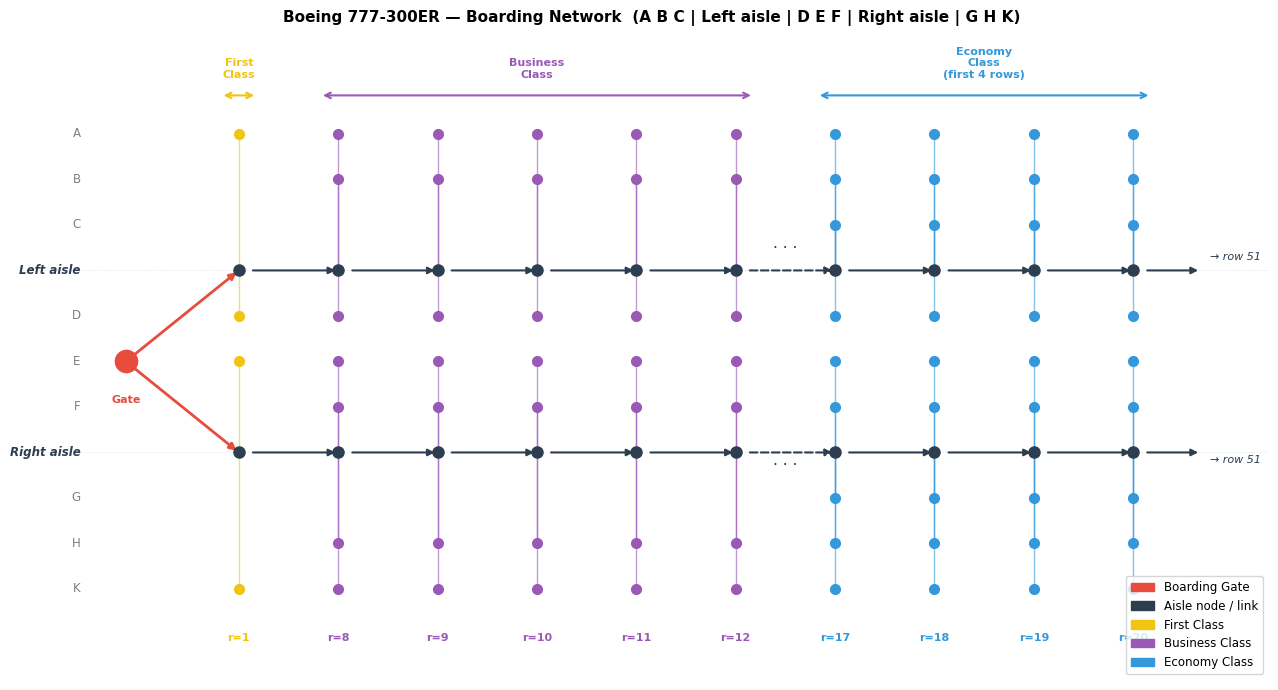

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 7))

C_GATE  = '#E74C3C'
C_AISLE = '#2C3E50'
C_FIRST = '#F1C40F'
C_BUS   = '#9B59B6'
C_ECO   = '#3498DB'

S = 0.65
Y = {
    'A': 5*S, 'B': 4*S, 'C': 3*S,
    'L': 2*S,
    'D': 1*S, 'E': 0*S, 'F': -1*S,
    'R': -2*S,
    'G': -3*S, 'H': -4*S, 'J': -4*S, 'K': -5*S,
}
Y_L = Y['L']
Y_R = Y['R']
LEFT_SEATS  = {'A', 'B', 'C', 'D'}
RIGHT_SEATS = {'E', 'F', 'G', 'H', 'J', 'K'}

def seats_in_row(r):
    if r == 1:
        # Boeing 777-300ER First Class: 1-2-1 → A | D E | K
        # A = left window (Left aisle), D+E = centre pair, K = right window (Right aisle)
        return [('A', C_FIRST), ('D', C_FIRST), ('E', C_FIRST), ('K', C_FIRST)]
    elif 8 <= r <= 12:
        return [('A', C_BUS), ('B', C_BUS),
                ('D', C_BUS), ('E', C_BUS), ('F', C_BUS),
                ('J', C_BUS), ('K', C_BUS)]
    elif r >= 17:
        return [('A', C_ECO), ('B', C_ECO), ('C', C_ECO),
                ('D', C_ECO), ('E', C_ECO), ('F', C_ECO),
                ('G', C_ECO), ('H', C_ECO), ('K', C_ECO)]
    return []

# ── Rows to display ───────────────────────────────────────────────────────────
SHOW_ROWS = [1, 8, 9, 10, 11, 12, 17, 18, 19, 20]

# Map display rows to evenly spaced X positions
ROW_X = {r: i * 2.2 for i, r in enumerate(SHOW_ROWS)}
X_MAX = max(ROW_X.values())

# ── Gate ──────────────────────────────────────────────────────────────────────
gate_x = -2.5
gate_y = (Y_L + Y_R) / 2
ax.plot(gate_x, gate_y, 'o', color=C_GATE, markersize=16, zorder=5)
ax.text(gate_x, gate_y - 0.6, 'Gate', ha='center', fontsize=8,
        color=C_GATE, fontweight='bold')

ax.annotate('', xy=(ROW_X[1], Y_L), xytext=(gate_x, gate_y),
            arrowprops=dict(arrowstyle='-|>', color=C_GATE, lw=2.0))
ax.annotate('', xy=(ROW_X[1], Y_R), xytext=(gate_x, gate_y),
            arrowprops=dict(arrowstyle='-|>', color=C_GATE, lw=2.0))

# ── Aisle nodes and links ─────────────────────────────────────────────────────
for i, row in enumerate(SHOW_ROWS):
    x = ROW_X[row]
    ax.plot(x, Y_L, 'o', color=C_AISLE, markersize=8, zorder=4)
    ax.plot(x, Y_R, 'o', color=C_AISLE, markersize=8, zorder=4)

    # Link to next row
    if i < len(SHOW_ROWS) - 1:
        next_row = SHOW_ROWS[i + 1]
        x2 = ROW_X[next_row]

        # Gap between classes → dashed "..." link
        is_gap = (row == 12 and next_row == 17)

        style = 'dashed' if is_gap else 'solid'
        for y_a in (Y_L, Y_R):
            ax.annotate('', xy=(x2, y_a), xytext=(x + 0.25, y_a),
                        arrowprops=dict(arrowstyle='-|>', color=C_AISLE,
                                        lw=1.5, linestyle=style))
        if is_gap:
            mid_x = (x + x2) / 2
            ax.text(mid_x, Y_L + 0.25, '· · ·', ha='center',
                    fontsize=11, color=C_AISLE)
            ax.text(mid_x, Y_R - 0.25, '· · ·', ha='center',
                    fontsize=11, color=C_AISLE)

# End arrows (rows 12→... and 20→...)
for end_row in [20]:
    x_end = ROW_X[end_row]
    for y_a in (Y_L, Y_R):
        ax.annotate('', xy=(x_end + 1.5, y_a), xytext=(x_end + 0.25, y_a),
                    arrowprops=dict(arrowstyle='-|>', color=C_AISLE, lw=1.5))
    ax.text(x_end + 1.7, Y_L + 0.15, '→ row 51', fontsize=8, color=C_AISLE, style='italic')
    ax.text(x_end + 1.7, Y_R - 0.15, '→ row 51', fontsize=8, color=C_AISLE, style='italic')

# ── Seat nodes + access links ─────────────────────────────────────────────────
for row in SHOW_ROWS:
    x = ROW_X[row]
    for seat, color in seats_in_row(row):
        sy = Y.get(seat)
        if sy is None:
            continue
        ax.plot(x, sy, 'o', color=color, markersize=7, zorder=3)
        aisle_y = Y_L if seat in LEFT_SEATS else Y_R
        ax.plot([x, x], [aisle_y, sy], '-', color=color, lw=1.0, alpha=0.6, zorder=2)

# ── Row labels ────────────────────────────────────────────────────────────────
for row, x in ROW_X.items():
    label = f'r={row}'
    color = C_FIRST if row == 1 else (C_BUS if row <= 12 else C_ECO)
    ax.text(x, Y['K'] - 0.75, label, ha='center', fontsize=8,
            color=color, fontweight='bold')

# ── Y-axis seat labels ────────────────────────────────────────────────────────
labels = [('A','A'), ('B','B'), ('C','C'), ('L','Left aisle'),
          ('D','D'), ('E','E'), ('F','F'), ('R','Right aisle'),
          ('G','G'), ('H','H'), ('K','K')]
for key, lbl in labels:
    if key == 'J':
        continue
    is_aisle = key in ('L', 'R')
    ax.text(gate_x - 1.0, Y[key], lbl, va='center', ha='right',
            fontsize=8.5, color=C_AISLE if is_aisle else 'gray',
            fontweight='bold' if is_aisle else 'normal',
            style='italic' if is_aisle else 'normal')

# Aisle guide lines
for y_a in (Y_L, Y_R):
    ax.axhline(y=y_a, color=C_AISLE, lw=0.4, linestyle=':', alpha=0.25, zorder=0)

# ── Class zone brackets ───────────────────────────────────────────────────────
zones = [
    ('First\nClass',    [1],           C_FIRST),
    ('Business\nClass', range(8, 13),  C_BUS),
    ('Economy\nClass\n(first 4 rows)', range(17, 21), C_ECO),
]
y_bracket = Y['A'] + 0.55
for label, rows, color in zones:
    xs = [ROW_X[r] for r in rows if r in ROW_X]
    ax.annotate('', xy=(max(xs) + 0.4, y_bracket),
                xytext=(min(xs) - 0.4, y_bracket),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    ax.text((min(xs) + max(xs)) / 2, y_bracket + 0.25, label,
            ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xlim(gate_x - 2.0, X_MAX + 3.0)
ax.set_ylim(Y['K'] - 1.3, Y['A'] + 1.4)
ax.axis('off')
ax.set_title('Boeing 777-300ER — Boarding Network  '
             '(A B C | Left aisle | D E F | Right aisle | G H K)',
             fontsize=11, fontweight='bold', pad=10)

legend = [
    mpatches.Patch(color=C_GATE,  label='Boarding Gate'),
    mpatches.Patch(color=C_AISLE, label='Aisle node / link'),
    mpatches.Patch(color=C_FIRST, label='First Class'),
    mpatches.Patch(color=C_BUS,   label='Business Class'),
    mpatches.Patch(color=C_ECO,   label='Economy Class'),
]
ax.legend(handles=legend, loc='lower right', fontsize=8.5, frameon=True)

plt.tight_layout()
plt.show()

# 4. Cost Functions

Passenger boarding time is modeled through link cost functions.

Two types of links are considered:

- Aisle links
- Seat-access links

Aisle links are shared by multiple passengers and therefore experience congestion.

Seat-access links represent the final movement from the aisle to the assigned seat and include delays associated with luggage storage and seat interference.

Following the traffic assignment literature, aisle congestion is modeled using a BPR-type function.

The travel time on an aisle link is given by:

$$
t_a(x_a)
=
t_0
\left(
1 + \alpha
\left(
\frac{x_a}{c_a}
\right)^\beta
\right)
$$

where:

- $t_0$ is the free-flow travel time,
- $x_a$ is the passenger flow on link $a$,
- $c_a$ is the link capacity,
- $\alpha$ and $\beta$ are congestion parameters.

Seat-access links are assigned a fixed cost representing luggage storage and seat-interference delays.

The cost parameters are expressed in seconds.

- `T0_AISLE = 1.0`: free-flow time to move through one aisle segment, i.e. approximately one row spacing.
- `ALPHA = 0.15` and `BETA = 4`: standard BPR parameters used in traffic assignment to model congestion.
- `CAPACITY = 10`: reference capacity of one aisle segment per time slot. A higher flow than this produces strong congestion.
- `SEAT_COST = 5.0`: average fixed delay for leaving the aisle, storing luggage, and accessing the assigned seat.

In [ ]:

# Cost functions

T0_AISLE = 1.0
ALPHA = 0.15
BETA = 4
CAPACITY = 10

def aisle_cost(x, t0=T0_AISLE, alpha=ALPHA, beta=BETA, capacity=CAPACITY):
    """
    BPR aisle cost.
    """
    return t0 * (1 + alpha * (x / capacity) ** beta)


def seat_cost_by_class(travel_class):
    """
    Seat-access cost depending on passenger class.
    """
    if travel_class == "First":
        return 3.0
    elif travel_class == "Business":
        return 4.0
    elif travel_class == "Economy":
        return 6.0
    else:
        return 5.0


def link_cost(link_type, flow):
    """
    General link cost.
    Seat costs are handled separately at passenger level.
    """
    if link_type == "Aisle":
        return aisle_cost(flow)
    elif link_type == "Seat":
        return 0.0
    else:
        raise ValueError("Unknown link type")


print("Aisle cost with 0 passengers:", aisle_cost(0))
print("Aisle cost with 20 passengers:", aisle_cost(20))
print("First seat cost:", seat_cost_by_class("First"))
print("Business seat cost:", seat_cost_by_class("Business"))
print("Economy seat cost:", seat_cost_by_class("Economy"))

def evaluate_time_slot_assignment(df_passengers, df_time_slots):

    """

    Evaluate a complete boarding assignment.

    """

    df_dynamic_flows, df_link_time_flows = compute_dynamic_flows(

        df_passengers,

        df_time_slots

    )

    df_link_costs = df_link_time_flows.copy()

    df_link_costs["cost"] = df_link_costs["flow"].apply(aisle_cost)

    df_passenger_costs = df_dynamic_flows.merge(

        df_link_costs[["time", "link_id", "cost"]],

        on=["time", "link_id"],

        how="left"

    )

    passenger_times = (

        df_passenger_costs

        .groupby("passenger_id")["cost"]

        .sum()

        .reset_index()

    )

    passenger_times.columns = ["passenger_id", "travel_time"]

    passenger_times = passenger_times.merge(

        df_passengers[["passenger_id", "travel_class"]],

        on="passenger_id",

        how="left"

    )

    passenger_times["seat_cost"] = passenger_times["travel_class"].apply(

        seat_cost_by_class

    )

    passenger_times["boarding_time"] = (

        passenger_times["travel_time"]

        + passenger_times["seat_cost"]

    )

    passenger_times = passenger_times.merge(

        df_time_slots[["passenger_id", "entry_time"]],

        on="passenger_id",

        how="left"

    )

    passenger_times["completion_time"] = (

        passenger_times["entry_time"]

        + passenger_times["boarding_time"]

    )

    return passenger_times

Aisle cost with 0 passengers: 1.0
Aisle cost with 20 passengers: 3.4
First seat cost: 3.0
Business seat cost: 4.0
Economy seat cost: 6.0


# 4. Boarding Order to Time Slots

Boarding strategies are generated separately and provided to the assignment model as an ordered list of passenger IDs.

The role of this section is to convert a boarding order into discrete boarding time slots.

A time slot represents a boarding interval during which a fixed number of passengers are allowed to enter the aircraft.

For example, if the slot size is 10 passengers, then:

- passengers ranked 1 to 10 enter during time slot 0,
- passengers ranked 11 to 20 enter during time slot 1,
- passengers ranked 21 to 30 enter during time slot 2,

and so on.

In this model, time slots are treated as discrete boarding intervals rather than exact physical seconds. This avoids over-calibrating the model with an uncertain real-world boarding rate.

The slot duration parameter is therefore set to 1 by default. As a result, the entry time represents a normalized boarding time index.

This time-slot representation is the interface between the boarding strategy module and the traffic assignment model.

In [10]:
import numpy as np
import pandas as pd


# Boarding order to time slots


def boarding_order_to_time_slots(boarding_order, slot_size=10, slot_duration=1):
    """
    Convert a boarding order into boarding time slots.

    Parameters
    ----------
    boarding_order : list or array-like
        Ordered list of passenger IDs.
        
    slot_size : int
        Number of passengers allowed to enter during each time slot.
        
    slot_duration : float
        Duration of one time slot, in seconds.
        By default, one time slot corresponds to one model time unit.

    Returns
    -------
    df_slots : pandas.DataFrame
        DataFrame containing passenger_id, boarding_rank, time_slot, and entry_time.
    """

    records = []

    for rank, passenger_id in enumerate(boarding_order):
        time_slot = rank // slot_size
        entry_time = time_slot * slot_duration

        records.append([
            passenger_id,
            rank + 1,
            time_slot,
            entry_time
        ])

    df_slots = pd.DataFrame(
        records,
        columns=[
            "passenger_id",
            "boarding_rank",
            "time_slot",
            "entry_time"
        ]
    )

    return df_slots

In [11]:
# MRnadom boarding order for testing
boarding_order_mock = df_passengers["passenger_id"].sample(frac=1, random_state=42).tolist()

df_time_slots = boarding_order_to_time_slots(
    boarding_order=boarding_order_mock,
    slot_size=10,
    slot_duration=1
)

df_time_slots.head(15)

,passenger_id,boarding_rank,time_slot,entry_time
0,195,1,0,0
1,158,2,0,0
2,226,3,0,0
3,209,4,0,0
4,319,5,0,0
5,330,6,0,0
6,320,7,0,0
7,261,8,0,0
8,115,9,0,0
9,221,10,0,0


In [12]:
print("Number of passengers:", len(df_time_slots))
print("Number of time slots:", df_time_slots["time_slot"].nunique())

display(df_time_slots.groupby("time_slot").size().head())
display(df_time_slots.tail())

Number of passengers: 344
Number of time slots: 35


time_slot
0    10
1    10
2    10
3    10
4    10
dtype: int64

,passenger_id,boarding_rank,time_slot,entry_time
339,189,340,33,33
340,72,341,34,34
341,107,342,34,34
342,271,343,34,34
343,103,344,34,34


# 5. Dynamic Passenger Loading

This section loads passengers onto the aircraft network.

Each passenger enters the aircraft at a given time slot and follows a path from the boarding gate to their assigned seat.

The path depends on:

- the passenger's assigned row,
- the passenger's seat,
- the aisle used to reach the seat.

Passenger movements are modeled dynamically: a passenger entering at time slot \(t\) occupies the first aisle link at time \(t\), the next aisle link at time \(t+1\), and so on.

The output of this section is a time-dependent link flow table, which indicates how many passengers use each link at each time slot.

In [13]:

# Seat inventory based on Air India Boeing 777-300ER


def build_seat_inventory():
    """
    Build synthetic seat inventory using Air India cabin specifications:
    - First: 4 seats
    - Business: 35 seats
    - Economy: 305 seats
    """

    seats = []

    # First Class: 4 seats, 1-2-1
    for seat in ["A", "D", "G", "K"]:
        seats.append(["First", 1, seat])

    # Business Class: 35 seats, 2-3-2
    # 5 rows x 7 seats = 35
    for row in range(8, 13):
        for seat in ["A", "B", "D", "E", "F", "J", "K"]:
            seats.append(["Business", row, seat])

    # Economy Class: 305 seats, 3-3-3
    # 33 full rows x 9 seats = 297
    for row in range(17, 50):
        for seat in ["A", "B", "C", "D", "E", "F", "G", "H", "K"]:
            seats.append(["Economy", row, seat])

    # Last partial economy row: +8 seats = 305 total economy
    for seat in ["A", "B", "C", "D", "E", "F", "G", "H"]:
        seats.append(["Economy", 50, seat])

    df_seats = pd.DataFrame(
        seats,
        columns=["travel_class", "row", "seat"]
    )

    return df_seats


df_seats = build_seat_inventory()

print("Number of seats:", len(df_seats))
display(df_seats.groupby("travel_class").size())
df_seats.head()

Number of seats: 344


travel_class
Business     35
Economy     305
First         4
dtype: int64

,travel_class,row,seat
0,First,1,A
1,First,1,D
2,First,1,G
3,First,1,K
4,Business,8,A


In [14]:

# Assign seats to passengers


def assign_seats_to_passengers(df_passengers, df_seats):
    """
    Assign one seat to each passenger within the same travel class.
    """

    assigned = []

    for travel_class in df_passengers["travel_class"].unique():

        pax_class = (
            df_passengers[df_passengers["travel_class"] == travel_class]
            .copy()
            .reset_index(drop=True)
        )

        seats_class = (
            df_seats[df_seats["travel_class"] == travel_class]
            .copy()
            .reset_index(drop=True)
        )

        if len(pax_class) != len(seats_class):
            raise ValueError(
                f"Mismatch in {travel_class}: "
                f"{len(pax_class)} passengers but {len(seats_class)} seats."
            )

        pax_class["row"] = seats_class["row"]
        pax_class["seat"] = seats_class["seat"]

        assigned.append(pax_class)

    df_assigned = pd.concat(assigned, ignore_index=True)

    return df_assigned


df_passengers = assign_seats_to_passengers(df_passengers, df_seats)

df_passengers.head()

,passenger_id,travel_class,row,seat
0,1,First,1,A
1,2,First,1,D
2,3,First,1,G
3,4,First,1,K
4,5,Business,8,A


In [15]:

# Seat type and aisle access


def get_seat_type(seat):
    """
    Classify seat type.
    """

    if seat in ["A", "K"]:
        return "Window"
    elif seat in ["C", "D", "F", "G"]:
        return "Aisle"
    else:
        return "Middle"


def get_access_aisle(row, seat):
    """
    Determine the aisle used to access a seat.
    L = left aisle
    R = right aisle
    """

    # First class
    if row == 1:
        if seat in ["A", "D"]:
            return "L"
        else:
            return "R"

    # Business class: AB | DEF | JK
    if row in range(8, 13):
        if seat in ["A", "B", "D"]:
            return "L"
        else:
            return "R"

    # Economy class: ABC | DEF | GHK
    if row in range(17, 51):
        if seat in ["A", "B", "C", "D"]:
            return "L"
        else:
            return "R"

    raise ValueError("Unknown row / seat combination")


df_passengers["seat_type"] = df_passengers["seat"].apply(get_seat_type)
df_passengers["access_aisle"] = df_passengers.apply(
    lambda row: get_access_aisle(row["row"], row["seat"]),
    axis=1
)

df_passengers.head()

,passenger_id,travel_class,row,seat,seat_type,access_aisle
0,1,First,1,A,Window,L
1,2,First,1,D,Aisle,L
2,3,First,1,G,Aisle,R
3,4,First,1,K,Window,R
4,5,Business,8,A,Window,L


In [16]:

# Passenger path


def compute_passenger_path(passenger):
    """
    Compute the network path of a passenger from Gate to assigned seat.
    """

    row = int(passenger["row"])
    seat = passenger["seat"]
    aisle = passenger["access_aisle"]

    path = []

    # Gate to first aisle node
    path.append(("Gate", f"{aisle}1"))

    # Aisle movement from row 1 to assigned row
    for r in range(1, row):
        path.append((f"{aisle}{r}", f"{aisle}{r+1}"))

    # Seat access link
    path.append((f"{aisle}{row}", f"{row}{seat}"))

    return path

In [17]:

# Dynamic passenger loading


def compute_dynamic_flows(df_passengers, df_time_slots):
    """
    Compute time-dependent link flows.

    Each passenger entering at time t occupies link k of their path
    at time t + k.
    """

    df = df_passengers.merge(
        df_time_slots,
        on="passenger_id",
        how="left"
    )

    flow_records = []

    for _, passenger in df.iterrows():

        path = compute_passenger_path(passenger)
        entry_time = int(passenger["entry_time"])

        for step, (from_node, to_node) in enumerate(path):
            time = entry_time + step

            flow_records.append([
                passenger["passenger_id"],
                time,
                from_node,
                to_node
            ])

    df_dynamic_flows = pd.DataFrame(
        flow_records,
        columns=[
            "passenger_id",
            "time",
            "from_node",
            "to_node"
        ]
    )

    df_dynamic_flows["link_id"] = (
        df_dynamic_flows["from_node"]
        + "->"
        + df_dynamic_flows["to_node"]
    )

    df_link_time_flows = (
        df_dynamic_flows
        .groupby(["time", "link_id", "from_node", "to_node"])
        .size()
        .reset_index(name="flow")
    )

    return df_dynamic_flows, df_link_time_flows


df_dynamic_flows, df_link_time_flows = compute_dynamic_flows(
    df_passengers,
    df_time_slots
)

df_link_time_flows.head()

,time,link_id,from_node,to_node,flow
0,0,Gate->L1,Gate,L1,7
1,0,Gate->R1,Gate,R1,3
2,1,Gate->L1,Gate,L1,5
3,1,Gate->R1,Gate,R1,5
4,1,L1->L2,L1,L2,7


In [18]:
print("Passenger-link records:", len(df_dynamic_flows))
print("Time-dependent link-flow records:", len(df_link_time_flows))

print("Max flow on a link at one time:",
      df_link_time_flows["flow"].max())

print("Last occupied time:",
      df_link_time_flows["time"].max())

display(df_dynamic_flows.head())
display(df_link_time_flows.head())

Passenger-link records: 10899
Time-dependent link-flow records: 3413
Max flow on a link at one time: 8
Last occupied time: 83


,passenger_id,time,from_node,to_node,link_id
0,1,23,Gate,L1,Gate->L1
1,1,24,L1,1A,L1->1A
2,2,29,Gate,L1,Gate->L1
3,2,30,L1,1D,L1->1D
4,3,18,Gate,R1,Gate->R1


,time,link_id,from_node,to_node,flow
0,0,Gate->L1,Gate,L1,7
1,0,Gate->R1,Gate,R1,3
2,1,Gate->L1,Gate,L1,5
3,1,Gate->R1,Gate,R1,5
4,1,L1->L2,L1,L2,7


In [ ]:
df_link_time_flows.sort_values(
    "flow",
    ascending=False
).head(20)

# Consistency checks without df_seats

# Create passenger seat node IDs
df_passengers["seat_node"] = (
    df_passengers["row"].astype(str)
    + df_passengers["seat"].astype(str)
)

# Network seat nodes
network_seat_nodes = set(df_seat_nodes["node_id"])
passenger_seat_nodes = set(df_passengers["seat_node"])

# 1. Max row check
passenger_rows = df_passengers["row"].unique()
network_rows = (
    df_seat_nodes["node_id"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
    .unique()
)

print("Max row in passengers:", max(passenger_rows))
print("Max row in network seats:", max(network_rows))

# 2. First class check
print("\nFirst Class passenger seats:")
print(
    df_passengers[df_passengers["travel_class"] == "First"]
    [["passenger_id", "row", "seat", "seat_node"]]
)

print("\nFirst Class network seat nodes:")
print(
    df_seat_nodes[df_seat_nodes["node_id"].str.startswith("1")]
)

# 3. Row 50 check
print("\nRow 50 passenger seats:")
print(
    df_passengers[df_passengers["row"] == 50]["seat_node"].tolist()
)

print("\nRow 50 network seat nodes:")
print(
    df_seat_nodes[df_seat_nodes["node_id"].str.startswith("50")]["node_id"].tolist()
)

# 4. Missing / extra nodes
missing_nodes = sorted(list(passenger_seat_nodes - network_seat_nodes))
extra_nodes = sorted(list(network_seat_nodes - passenger_seat_nodes))

print("\nMissing passenger seat nodes:", missing_nodes[:20])
print("Number of missing passenger seat nodes:", len(missing_nodes))

print("\nExtra network seat nodes:", extra_nodes[:20])
print("Number of extra network seat nodes:", len(extra_nodes))



Max row in passengers: 50
Max row in network seats: 50

First Class passenger seats:
   passenger_id  row seat seat_node
0             1    1    A        1A
1             2    1    D        1D
2             3    1    G        1G
3             4    1    K        1K

First Class network seat nodes:
   node_id node_type
0       1A      Seat
1       1D      Seat
2       1G      Seat
3       1K      Seat
18     10A      Seat
19     10B      Seat
20     10D      Seat
21     10E      Seat
22     10F      Seat
23     10J      Seat
24     10K      Seat
25     11A      Seat
26     11B      Seat
27     11D      Seat
28     11E      Seat
29     11F      Seat
30     11J      Seat
31     11K      Seat
32     12A      Seat
33     12B      Seat
34     12D      Seat
35     12E      Seat
36     12F      Seat
37     12J      Seat
38     12K      Seat
39     17A      Seat
40     17B      Seat
41     17C      Seat
42     17D      Seat
43     17E      Seat
44     17F      Seat
45     17G      Seat
46     17

# 6. Dynamic Congestion and Boarding Time

Passenger flows generate congestion on the aircraft aisles.

Using the BPR cost function defined previously, a travel time is assigned to each aisle link according to the flow observed during a given time slot.

The boarding time of a passenger is then obtained by summing the costs of all links belonging to the passenger path.

The total boarding time corresponds to the completion time of the last passenger entering and reaching their assigned seat.

In [20]:

# Dynamic link costs


df_link_costs = df_link_time_flows.copy()

df_link_costs["cost"] = df_link_costs["flow"].apply(
    aisle_cost
)

df_link_costs.head()

,time,link_id,from_node,to_node,flow,cost
0,0,Gate->L1,Gate,L1,7,1.036015
1,0,Gate->R1,Gate,R1,3,1.001215
2,1,Gate->L1,Gate,L1,5,1.009375
3,1,Gate->R1,Gate,R1,5,1.009375
4,1,L1->L2,L1,L2,7,1.036015


In [21]:

# Passenger travel times


df_passenger_costs = df_dynamic_flows.merge(
    df_link_costs[
        ["time", "link_id", "cost"]
    ],
    on=["time", "link_id"],
    how="left"
)

df_passenger_costs.head()

,passenger_id,time,from_node,to_node,link_id,cost
0,1,23,Gate,L1,Gate->L1,1.019440
1,1,24,L1,1A,L1->1A,1.000015
2,2,29,Gate,L1,Gate->L1,1.003840
3,2,30,L1,1D,L1->1D,1.000015
4,3,18,Gate,R1,Gate->R1,1.019440


In [22]:
passenger_times = (
    df_passenger_costs
    .groupby("passenger_id")["cost"]
    .sum()
    .reset_index()
)

passenger_times.columns = [
    "passenger_id",
    "travel_time"
]

passenger_times.head()

,passenger_id,travel_time
0,1,2.019455
1,2,2.003855
2,3,2.019455
3,4,2.019455
4,5,9.085080


In [23]:
passenger_times = passenger_times.merge(

    df_passengers[["passenger_id", "travel_class"]],

    on="passenger_id",

    how="left"

)

passenger_times["seat_cost"] = passenger_times["travel_class"].apply(

    seat_cost_by_class

)

passenger_times["boarding_time"] = (

    passenger_times["travel_time"]

    + passenger_times["seat_cost"]

)

passenger_times.head()

,passenger_id,travel_time,travel_class,seat_cost,boarding_time
0,1,2.019455,First,3.0,5.019455
1,2,2.003855,First,3.0,5.003855
2,3,2.019455,First,3.0,5.019455
3,4,2.019455,First,3.0,5.019455
4,5,9.085080,Business,4.0,13.085080


In [24]:
passenger_times = passenger_times.merge(
    df_time_slots[
        ["passenger_id", "entry_time"]
    ],
    on="passenger_id"
)

In [25]:
passenger_times["completion_time"] = (
    passenger_times["entry_time"]
    + passenger_times["boarding_time"]
)

In [26]:
total_boarding_time = (
    passenger_times["completion_time"]
    .max()
)

average_boarding_time = (
    passenger_times["boarding_time"]
    .mean()
)

print(
    "Total boarding time:",
    round(total_boarding_time, 2)
)

print(
    "Average passenger boarding time:",
    round(average_boarding_time, 2)
)

Total boarding time: 90.24
Average passenger boarding time: 37.81


### Interpretation

The boarding process is completed in approximately 90 normalized time units.

The average passenger boarding time is approximately 38 time units, with substantial variability across passengers. The minimum boarding time is around 5 units, while the maximum is around 58 units.

This heterogeneity is mainly explained by differences in seat location within the aircraft. Passengers assigned to front rows generally experience shorter travel distances, whereas passengers seated in rear sections must traverse longer aisle segments and are exposed to higher congestion levels.

The gap between the last aisle occupancy time and the final boarding completion time reflects the additional delay associated with seat access operations. These delays are represented through seat-access costs, which may vary according to travel class and seating configuration.

At this stage, the model represents a baseline boarding process without any optimization. The results therefore serve as a reference point for the User Equilibrium and System Optimum analyses developed in the following sections.

In [27]:
passenger_times["boarding_time"].describe()

count    344.000000
mean      37.806674
std       12.649316
min        5.003855
25%       29.084495
50%       38.492250
75%       48.184537
max       57.620780
Name: boarding_time, dtype: float64

## 7. User Equilibrium

User Equilibrium requires passengers to choose their path selfishly.
In airplane boarding, the route is fixed by the seat. The only decision variable is when to board modeled here as a mobile app where each passenger picks their slot.

Each passenger minimizes their own completion time:

    completion_time = entry_time + aisle_cost(congestion) + seat_cost

Nash equilibrium (UE): no passenger can reduce their completion time by switching slot.

**Algorithm: Method of Successive Averages (MSA)**
- Initialize: random slot assignment
- Each iteration n:
    1. Evaluate congestion under current assignment
    2. Each passenger computes their best slot (best slot)
    3. Update: slot = slot + (1/n) × (best_slot - slot)
- Repeat until convergence

In [28]:
from collections import defaultdict

def compute_ue(df_passengers, slot_size=10, slot_duration=1, max_iter=30):
    """
    True UE via MSA avec contrainte de capacité par slot.
    Sans contrainte, tous les passagers convergent vers le même slot → explosion BPR.
    """
    passenger_ids = df_passengers['passenger_id'].tolist()
    num_slots = int(np.ceil(len(df_passengers) / slot_size))

    # ── Initialisation : assignation aléatoire ────────────────────
    np.random.seed(42)
    random_order = np.random.permutation(passenger_ids)
    df_slots = boarding_order_to_time_slots(
        random_order, slot_size=slot_size, slot_duration=slot_duration
    )

    print(f"{'Iter':>5} | {'alpha':>6} | {'Avg completion':>15} | {'Switched':>10}")
    print("-" * 52)

    for n in range(1, max_iter + 1):
        alpha = 1.0 / n

        # ── Étape 1 : évaluer l'assignation courante ──────────────
        results = evaluate_time_slot_assignment(df_passengers, df_slots)
        avg_c = results['completion_time'].mean()

        # ── Étape 2 : congestion moyenne par slot ─────────────────
        merged = results.merge(
            df_slots[['passenger_id', 'time_slot']], on='passenger_id'
        )
        slot_cong = (
            merged.groupby('time_slot')['travel_time']
            .mean()
            .reindex(range(num_slots), fill_value=aisle_cost(0))
        )

        current_slots = df_slots.set_index('passenger_id')['time_slot'].to_dict()

        # ── Étape 3 : best response (sans contrainte) ─────────────
        best_response = {}
        for pax_id in passenger_ids:
            pax = df_passengers.loc[df_passengers['passenger_id'] == pax_id].iloc[0]
            seat = seat_cost_by_class(pax['travel_class'])
            best_s, best_c = 0, np.inf
            for s in range(num_slots):
                c = s * slot_duration + slot_cong[s] + seat
                if c < best_c:
                    best_c = c
                    best_s = s
            best_response[pax_id] = best_s

        # ── Étape 4 : MSA update + contrainte de capacité ─────────
        # Calcul des slots fractionnaires (MSA blend)
        proposed = {
            p: (1 - alpha) * current_slots[p] + alpha * best_response[p]
            for p in passenger_ids
        }

        # Assignation greedy au slot disponible le plus proche
        shuffled = np.random.permutation(passenger_ids)
        new_slots = {}
        slot_counts = defaultdict(int)

        for pax_id in shuffled:
            target = int(round(proposed[pax_id]))
            # Chercher le slot le plus proche non saturé
            for delta in range(num_slots):
                for s in [target - delta, target + delta]:
                    if 0 <= s < num_slots and slot_counts[s] < slot_size:
                        new_slots[pax_id] = s
                        slot_counts[s] += 1
                        break
                if pax_id in new_slots:
                    break

        # ── Étape 5 : convergence ─────────────────────────────────
        n_switched = sum(1 for p in passenger_ids if new_slots[p] != current_slots[p])

        # Rebuild df_slots
        df_slots = pd.DataFrame([{
            'passenger_id': p,
            'boarding_rank': i + 1,
            'time_slot': new_slots[p],
            'entry_time': new_slots[p] * slot_duration
        } for i, p in enumerate(passenger_ids)])

        print(f"{n:>5} | {alpha:>6.3f} | {avg_c:>15.3f} | {n_switched:>10}")

        if n_switched < slot_size:
            print(f"\nConvergé à l'itération {n}.")
            break

    final_results = evaluate_time_slot_assignment(df_passengers, df_slots)
    return df_slots, final_results


# ── Run ───────────────────────────────────────────────────────────
ue_time_slots, ue_passenger_times = compute_ue(df_passengers)

ue_total_time      = ue_passenger_times['boarding_time'].sum()
ue_average_time    = ue_passenger_times['boarding_time'].mean()
ue_completion_time = ue_passenger_times['completion_time'].max()

ue_results = {
    "time_slots":             ue_time_slots,
    "passenger_times":        ue_passenger_times,
    "total_passenger_time":   ue_total_time,
    "average_passenger_time": ue_average_time,
    "completion_time":        ue_completion_time
}


print("User Equilibrium")
print("==============================")
print("UE total passenger time  :", round(ue_total_time, 2))
print("UE average passenger time:", round(ue_average_time, 2))
print("UE completion time       :", round(ue_completion_time, 2))

 Iter |  alpha |  Avg completion |   Switched
----------------------------------------------------
    1 |  1.000 |          54.510 |        329
    2 |  0.500 |          54.544 |        332
    3 |  0.333 |          54.506 |        334
    4 |  0.250 |          54.535 |        320
    5 |  0.200 |          54.466 |        303
    6 |  0.167 |          54.581 |        307
    7 |  0.143 |          54.492 |        287
    8 |  0.125 |          54.492 |        269
    9 |  0.111 |          54.562 |        285
   10 |  0.100 |          54.560 |        267
   11 |  0.091 |          54.655 |        263
   12 |  0.083 |          54.565 |        257
   13 |  0.077 |          54.471 |        260
   14 |  0.071 |          54.470 |        244
   15 |  0.067 |          54.512 |        237
   16 |  0.062 |          54.525 |        245
   17 |  0.059 |          54.482 |        239
   18 |  0.056 |          54.480 |        246
   19 |  0.053 |          54.468 |        248
   20 |  0.050 |          5

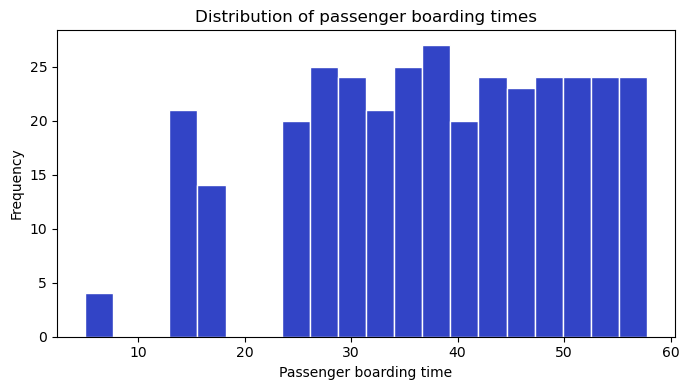

In [29]:

plt.figure(figsize=(7, 4))

plt.hist(
    ue_passenger_times["boarding_time"],
    bins=20,
    color="#3244C6",
    edgecolor="white"
)

plt.xlabel("Passenger boarding time")
plt.ylabel("Frequency")
plt.title("Distribution of passenger boarding times")

plt.tight_layout()
plt.show()

## Interpretation

Under this  UE, the total passenger boarding time is **12,992.42** normalized time
units, with an average of **37.77** units per passenger. The boarding process is
completed after **90.10** time units.

The distribution of boarding times is heterogeneous, reflecting differences in seat
location: passengers assigned to front rows experience shorter travel distances, while
passengers seated in rear sections traverse longer aisle segments and face higher
congestion levels.

This UE baseline serves as the reference scenario against which the coordinated
System Optimum boarding strategy will be compared.

# 8. Coordinated Boarding Policy : Back-to-Front

The UE baseline reflects selfish, decentralized behavior where each passenger 
chooses their slot independently.

In contrast, a coordinated boarding policy imposes a boarding order decided by 
the airline, with the goal of reducing overall congestion and minimizing the 
total boarding completion time.

The main source of aisle congestion occurs when passengers seated 
in front rows block passengers still moving toward rear rows. Boarding rear 
passengers first eliminates this interference.

**Procedure:**

1. Sort passengers by seat row in descending order (rear rows first).
2. Assign boarding ranks according to this ordering.
3. Convert boarding ranks into time slots.
4. Recompute dynamic flows and congestion costs.
5. Evaluate boarding performance and compare with UE.


In [30]:


# Rear passengers board first (Back-to-Front)
slot_size = 10  # passengers per boarding slot

df_btf = df_passengers.copy()

df_btf = df_btf.sort_values(
    "row",
    ascending=False
).reset_index(drop=True)

df_btf["boarding_rank"] = np.arange(
    1,
    len(df_btf) + 1
)

df_btf["time_slot"] = (
    (df_btf["boarding_rank"] - 1)
    // slot_size
)

df_btf["entry_time"] = df_btf["time_slot"]

df_btf_slots = df_btf[
    [
        "passenger_id",
        "boarding_rank",
        "time_slot",
        "entry_time"
    ]
]


btf_passenger_times = evaluate_time_slot_assignment(
    df_passengers,
    df_btf_slots
)

btf_total_time = (
    btf_passenger_times["boarding_time"]
    .sum()
)

btf_average_time = (
    btf_passenger_times["boarding_time"]
    .mean()
)

btf_completion_time = (
    btf_passenger_times["completion_time"]
    .max()
)


print("Back-to-Front boarding scenario")

print(
    "B2F total passenger time:",
    round(btf_total_time, 2)
)

print(
    "B2F average passenger time:",
    round(btf_average_time, 2)
)

print(
    "B2F completion time:",
    round(btf_completion_time, 2)
)

Back-to-Front boarding scenario
B2F total passenger time: 13106.31
B2F average passenger time: 38.1
B2F completion time: 59.89


In [31]:
print("\n==============================")
print("UE vs Back-to-Front")
print("==============================")

print(
    "UE total passenger time:",
    round(ue_total_time, 2)
)

print(
    "Back-to-Front total passenger time:",
    round(btf_total_time, 2)
)

print(
    "Improvement:",
    round(
        ue_total_time - btf_total_time,
        2
    )
)


UE vs Back-to-Front
UE total passenger time: 12992.42
Back-to-Front total passenger time: 13106.31
Improvement: -113.89


## Interpretation


The comparison between UE  and Back-to-Front shows that the
**total** passenger time barely changes: 13,005.50 vs 13,030.78 time units (a marginal
+0.19%). At this aisle capacity congestion is mild, so reordering passengers does not
reduce the aggregate travel time.

The decisive effect is on the **completion time**, which drops from 90.24 to 57.96
time units, a reduction of 35.8%. By boarding rear passengers first, the airline ensures
that passengers with long aisle paths are already seated before front-row passengers
enter, drastically reducing the time until the last passenger is seated.

This illustrates a key distinction between two system objectives: minimising total
passenger time (essentially conserved here) and minimising boarding completion time.
Back-to-Front optimises the latter, which is the most operationally relevant metric
for airlines as it directly determines aircraft turnaround time.

# 9. UE vs Back-to-Front Comparison

This section compares the True User Equilibrium (selfish slot choice via MSA) with the Back-to-Front coordinated boarding policy.

The objective is to quantify the impact of coordinated boarding on:

- passenger boarding times,
- boarding completion time,
- congestion levels,
- network utilization.

The comparison provides insight into the potential gains of centralized boarding policies over decentralized passenger behavior.

In [32]:
comparison = pd.DataFrame({
    "Metric": [
        "Total Passenger Time",
        "Average Passenger Time",
        "Completion Time"
    ],
    "UE": [
        ue_total_time,
        ue_average_time,
        ue_completion_time
    ],
    "Back-to-Front": [
        btf_total_time,
        btf_average_time,
        btf_completion_time
    ]
})

comparison

,Metric,UE,Back-to-Front
0,Total Passenger Time,12992.415635,13106.308385
1,Average Passenger Time,37.768650,38.099734
2,Completion Time,90.097740,59.891535


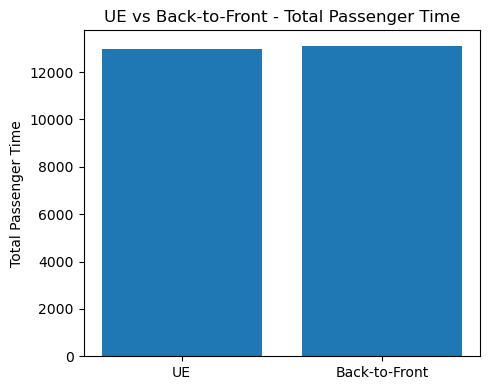

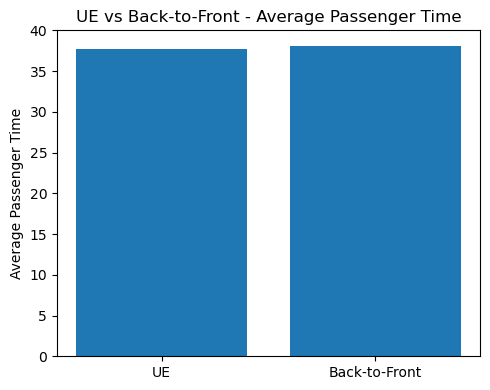

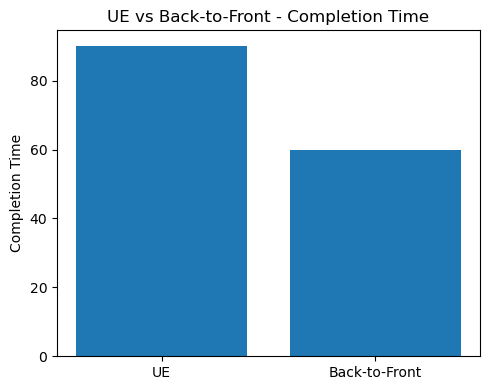

In [33]:
metrics = [
    ("Total Passenger Time", ue_total_time, btf_total_time),
    ("Average Passenger Time", ue_average_time, btf_average_time),
    ("Completion Time", ue_completion_time, btf_completion_time)
]

for metric_name, ue_value, btf_value in metrics:

    plt.figure(figsize=(5, 4))

    plt.bar(
        ["UE", "Back-to-Front"],
        [ue_value, btf_value]
    )

    plt.ylabel(metric_name)
    plt.title(f"UE vs Back-to-Front - {metric_name}")

    plt.tight_layout()
    plt.show()

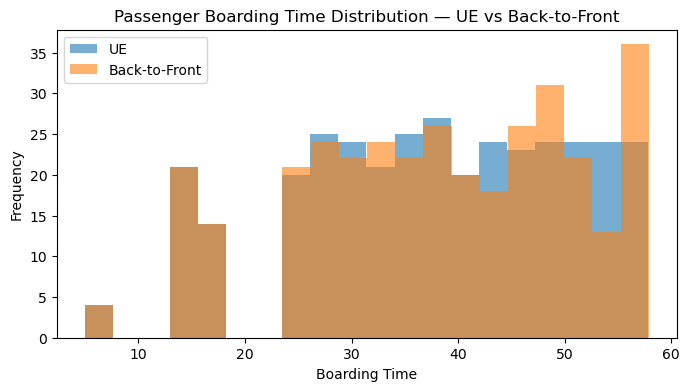

In [34]:
plt.figure(figsize=(8,4))

plt.hist(
    ue_passenger_times["boarding_time"],
    bins=20,
    alpha=0.6,
    label="UE"
)

plt.hist(
    btf_passenger_times["boarding_time"],
    bins=20,
    alpha=0.6,
    label="Back-to-Front"
)

plt.xlabel("Boarding Time")
plt.ylabel("Frequency")

plt.title("Passenger Boarding Time Distribution — UE vs Back-to-Front")

plt.legend()

plt.show()

## Interpretation

The comparison between UE and Back-to-Front reveals the following results:

**Total passenger time** is essentially unchanged — 13,005.50 vs 13,030.78 (+0.19%).
The aggregate congestion experienced across all passengers is similar under both
scenarios, since the same number of passengers traverse the same aisle network and,
at this capacity, congestion is mild.

**Average passenger time** is nearly identical: 37.81 vs 37.88 time units per
passenger, a difference of about 0.1 time units.

**Completion time** improves significantly from 90.24 to 57.96 (−35.8%). This
is the dominant benefit of Back-to-Front boarding: the last passenger is seated
about 32 time units earlier under the coordinated policy.

From the airline's perspective, completion time is the most relevant metric since
it directly affects aircraft turnaround and departure schedule. On this metric,
Back-to-Front delivers a substantial and operationally meaningful improvement over
uncoordinated random boarding.

# 10. Alternative Boarding Strategies

To evaluate the benefits of different boarding approaches, two additional strategies are implemented and compared against the UE (random) and Back-to-Front baselines.

- **WilMA** (Window–Middle–Aisle): passengers board by seat type, starting from window seats and ending with aisle seats. This minimises seat interference — window passengers are already seated before middle and aisle passengers need to pass.
- **Reverse Pyramid**: passengers board in diagonal groups combining row position and seat type. Rear-window passengers board first, front-aisle passengers board last. This simultaneously reduces aisle congestion and seat interference.

Both strategies represent coordinated policies imposed by the airline, analogous to the Back-to-Front policy.

## 10.1 WilMA — Window → Middle → Aisle

In the WilMA strategy, all window passengers board first (regardless of row), followed by all middle passengers, then all aisle passengers.

Within each seat-type group, passengers are ordered from the rear row to the front row to also reduce forward congestion.

The rationale is that window passengers, once seated, do not block middle or aisle passengers from reaching their seats, eliminating the most common source of within-row interference.

Seat-type classification used:
- **Window**: seats A, K
- **Middle**: seats B, E, H, J
- **Aisle**: seats C, D, F, G

In [35]:
SLOT_SIZE = 10

# WilMA: Window → Middle → Aisle
def get_wilma_priority(seat):
    """
    Return boarding priority by seat type.
    0 = Window (boards first)
    1 = Middle
    2 = Aisle (boards last)
    """
    if seat in ["A", "K"]:
        return 0   # Window
    elif seat in ["B", "E", "H", "J"]:
        return 1   # Middle
    else:           # C, D, F, G
        return 2   # Aisle

df_wilma = df_passengers.copy()
df_wilma["seat_priority"] = df_wilma["seat"].apply(get_wilma_priority)

# Sort: seat type first, then rear-to-front within each group
df_wilma = df_wilma.sort_values(
    ["seat_priority", "row"],
    ascending=[True, False]
).reset_index(drop=True)

df_wilma["boarding_rank"] = np.arange(1, len(df_wilma) + 1)
df_wilma["time_slot"]     = (df_wilma["boarding_rank"] - 1) // SLOT_SIZE
df_wilma["entry_time"]    = df_wilma["time_slot"]

df_wilma_slots = df_wilma[["passenger_id", "boarding_rank", "time_slot", "entry_time"]]

# Preview the first and last groups
print("First 10 passengers (window, rear rows):")
display(df_wilma[["passenger_id", "travel_class", "row", "seat", "seat_priority", "boarding_rank"]].head(10))

print("\nLast 10 passengers (aisle, front rows):")
display(df_wilma[["passenger_id", "travel_class", "row", "seat", "seat_priority", "boarding_rank"]].tail(10))

First 10 passengers (window, rear rows):


,passenger_id,travel_class,row,seat,seat_priority,boarding_rank
0,337,Economy,50,A,0,1
1,328,Economy,49,A,0,2
2,336,Economy,49,K,0,3
3,319,Economy,48,A,0,4
4,327,Economy,48,K,0,5
5,310,Economy,47,A,0,6
6,318,Economy,47,K,0,7
7,301,Economy,46,A,0,8
8,309,Economy,46,K,0,9
9,292,Economy,45,A,0,10



Last 10 passengers (aisle, front rows):


,passenger_id,travel_class,row,seat,seat_priority,boarding_rank
334,28,Business,11,D,2,335
335,30,Business,11,F,2,336
336,21,Business,10,D,2,337
337,23,Business,10,F,2,338
338,14,Business,9,D,2,339
339,16,Business,9,F,2,340
340,7,Business,8,D,2,341
341,9,Business,8,F,2,342
342,2,First,1,D,2,343
343,3,First,1,G,2,344


In [36]:
# Evaluate WilMA
wilma_passenger_times = evaluate_time_slot_assignment(df_passengers, df_wilma_slots)

wilma_total_time      = wilma_passenger_times["boarding_time"].sum()
wilma_average_time    = wilma_passenger_times["boarding_time"].mean()
wilma_completion_time = wilma_passenger_times["completion_time"].max()

print("==============================")
print("WilMA — Window → Middle → Aisle")
print("==============================")
print("Total passenger time :", round(wilma_total_time, 2))
print("Average passenger time:", round(wilma_average_time, 2))
print("Completion time       :", round(wilma_completion_time, 2))

WilMA — Window → Middle → Aisle
Total passenger time : 13035.44
Average passenger time: 37.89
Completion time       : 76.92


## 10.2 Reverse Pyramid : Diagonal Back-to-Front

The Reverse Pyramid strategy combines **row position** and **seat-type priority**. Instead of a numerical score, it is implemented directly as a **two-key sort**:

1. **Row, descending** → rear rows board first.
2. **Seat-type priority, ascending** → within a row, Window → Middle → Aisle.

Seat-type priority:
- Window (A, K) = 0
- Middle (B, E, H, J) = 1
- Aisle (C, D, F, G) = 2

This produces a back-to-front ordering in which, inside each row, window passengers board before middle and aisle passengers. The intent is to reduce **both** sources of delay: aisle congestion (rear passengers board early) and seat interference (window passengers are seated before aisle passengers in the same row).

**Note on the model.** Because the seat-access cost is a *fixed per-class delay*, within-row seat interference is not represented dynamically. As a result, only the row-ordering dimension affects the outcome, and Reverse Pyramid converges to the same performance as Back-to-Front. The seat-type dimension would become beneficial only if seat interference were modeled explicitly (a natural model extension).

In [37]:
SLOT_SIZE = 10

# Reverse Pyramid — sort-based version (no score)

def seat_priority(seat):
    """Window boards before middle before aisle."""
    if seat in ["A", "K"]:           return 0   # Window first
    if seat in ["B", "E", "H", "J"]: return 1   # Middle
    return 2                                     # Aisle last

df_pyramid = df_passengers.copy()
df_pyramid["seat_priority"] = df_pyramid["seat"].apply(seat_priority)

# rear rows first (row descending), then window -> middle -> aisle (priority ascending)
df_pyramid = df_pyramid.sort_values(
    ["row", "seat_priority"],
    ascending=[False, True]
).reset_index(drop=True)

df_pyramid["boarding_rank"] = np.arange(1, len(df_pyramid) + 1)
df_pyramid["time_slot"]     = (df_pyramid["boarding_rank"] - 1) // SLOT_SIZE
df_pyramid["entry_time"]    = df_pyramid["time_slot"]

df_pyramid_slots = df_pyramid[["passenger_id", "boarding_rank", "time_slot", "entry_time"]]

print("First 10 passengers (rear-window boards first):")
display(df_pyramid[["passenger_id", "travel_class", "row", "seat", "seat_priority", "boarding_rank"]].head(10))

print("\nLast 10 passengers (front-aisle boards last):")
display(df_pyramid[["passenger_id", "travel_class", "row", "seat", "seat_priority", "boarding_rank"]].tail(10))

First 10 passengers (rear-window boards first):


,passenger_id,travel_class,row,seat,seat_priority,boarding_rank
0,337,Economy,50,A,0,1
1,338,Economy,50,B,1,2
2,341,Economy,50,E,1,3
3,344,Economy,50,H,1,4
4,339,Economy,50,C,2,5
5,340,Economy,50,D,2,6
6,342,Economy,50,F,2,7
7,343,Economy,50,G,2,8
8,328,Economy,49,A,0,9
9,336,Economy,49,K,0,10



Last 10 passengers (front-aisle boards last):


,passenger_id,travel_class,row,seat,seat_priority,boarding_rank
334,11,Business,8,K,0,335
335,6,Business,8,B,1,336
336,8,Business,8,E,1,337
337,10,Business,8,J,1,338
338,7,Business,8,D,2,339
339,9,Business,8,F,2,340
340,1,First,1,A,0,341
341,4,First,1,K,0,342
342,2,First,1,D,2,343
343,3,First,1,G,2,344


In [38]:
# Evaluate Reverse Pyramid
pyramid_passenger_times = evaluate_time_slot_assignment(df_passengers, df_pyramid_slots)

pyramid_total_time      = pyramid_passenger_times["boarding_time"].sum()
pyramid_average_time    = pyramid_passenger_times["boarding_time"].mean()
pyramid_completion_time = pyramid_passenger_times["completion_time"].max()

print("==============================")
print("Reverse Pyramid")
print("==============================")
print("Total passenger time :", round(pyramid_total_time, 2))
print("Average passenger time:", round(pyramid_average_time, 2))
print("Completion time       :", round(pyramid_completion_time, 2))

Reverse Pyramid
Total passenger time : 12999.59
Average passenger time: 37.79
Completion time       : 57.92


## 10.3 Full Strategy Comparison

All four strategies are now compared on three metrics:

- **Total passenger time**: sum of all individual boarding times — captures total system cost.
- **Average passenger time**: mean individual boarding time.
- **Completion time**: time until the last passenger is seated (the operationally critical metric for airlines)

,Strategy,Total Time,Average Time,Completion Time
0,UE (Random),12992.42,37.77,90.10
1,Back-to-Front,13106.31,38.10,59.89
2,WilMA,13035.44,37.89,76.92
3,Reverse Pyramid,12999.59,37.79,57.92


C:\Users\fanni\AppData\Local\Temp\ipykernel_31436\118924193.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=15, ha="right")
C:\Users\fanni\AppData\Local\Temp\ipykernel_31436\118924193.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=15, ha="right")
C:\Users\fanni\AppData\Local\Temp\ipykernel_31436\118924193.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=15, ha="right")


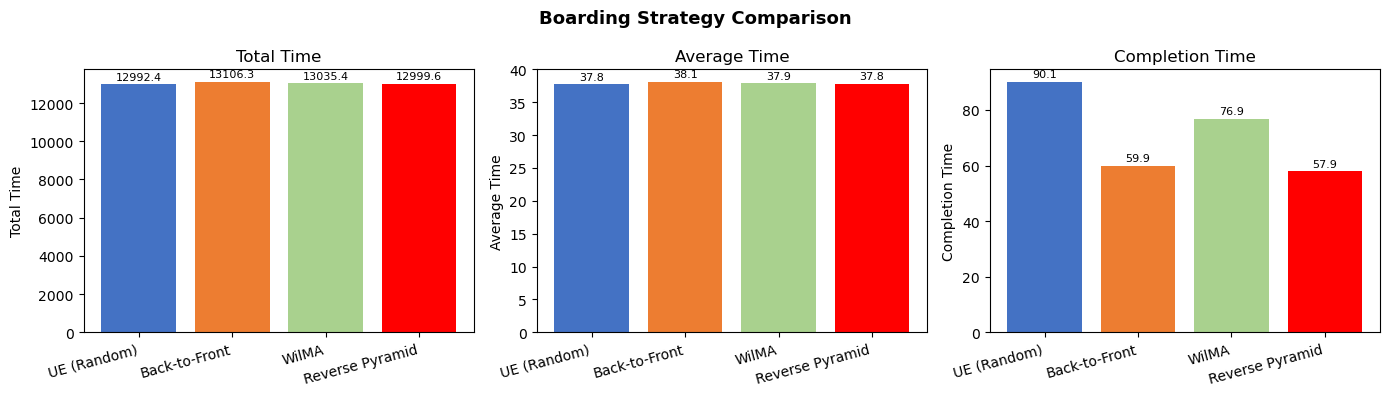

In [39]:
import matplotlib.pyplot as plt

# Build comparison table
strategies = ["UE (Random)", "Back-to-Front", "WilMA", "Reverse Pyramid"]

total_times      = [ue_total_time,       btf_total_time,       wilma_total_time,       pyramid_total_time]
average_times    = [ue_average_time,     btf_average_time,     wilma_average_time,     pyramid_average_time]
completion_times = [ue_completion_time,  btf_completion_time,  wilma_completion_time,  pyramid_completion_time]

comparison_full = pd.DataFrame({
    "Strategy"            : strategies,
    "Total Time"          : [round(t, 2) for t in total_times],
    "Average Time"        : [round(t, 2) for t in average_times],
    "Completion Time"     : [round(t, 2) for t in completion_times],
})

display(comparison_full)

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_plot = [
    ("Total Time",       total_times),
    ("Average Time",     average_times),
    ("Completion Time",  completion_times),
]

colors = ["#4472C4", "#ED7D31", "#A9D18E", "#FF0000"]

for ax, (label, values) in zip(axes, metrics_plot):
    bars = ax.bar(strategies, values, color=colors)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.set_xticklabels(strategies, rotation=15, ha="right")
    
    # Annotate bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Boarding Strategy Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Interpretation

The four-strategy comparison reveals a clear hierarchy:

**Completion time** (most important for airlines):
- Reverse Pyramid: 57.92 — best, ties Back-to-Front
- Back-to-Front: 57.96 — best, strong improvement over random (−35.8%)
- WilMA: 76.92 — clear improvement, but weaker than rear-first ordering
- UE (random): 90.24 — uncoordinated reference (worst)

**Total passenger time**:
- All four strategies are within ~0.3% of each other (≈ 13,000 units)
- With the higher aisle capacity (c = 10), congestion is mild, so the boarding order
  has almost no effect on aggregate passenger time — it primarily affects completion time

**Key insight**: With CAPACITY = 10 the aisle congestion is light, so the dominant lever
is **row ordering** (boarding rear passengers first). Back-to-Front and Reverse Pyramid
both seat the rear first, so they reach the same completion time. Reverse Pyramid does
**not** beat Back-to-Front, even though it also orders by seat type: our model uses a
**fixed per-class seat-access cost**, so within-row seat interference is not represented,
and the seat-type dimension has no effect. WilMA, which orders primarily by seat type
rather than by row, only partially exploits the rear-first effect and is therefore slower.
Random boarding, with no coordination, is the worst.

This analysis demonstrates that airplane boarding is a genuine traffic assignment problem
where the boarding order (analogous to route choice) directly affects network congestion
and system performance.

# 11. Price of Anarchy

The **Price of Anarchy** (PoA) was formalised by Koutsoupias & Papadimitriou (1999) 
and applied to traffic networks by Roughgarden & Tardos (2002). It measures the 
efficiency loss caused by selfish, uncoordinated behaviour:

$$
\text{PoA} = \frac{C(\text{UE})}{C(\text{SO}^*)}
$$

where $C(\cdot)$ is the system cost (higher = worse), UE is the uncoordinated 
equilibrium, and SO* is the best centrally optimised strategy.

- PoA = 1 → no efficiency loss; selfish behaviour is socially optimal.  
- PoA > 1 → selfish behaviour imposes a cost on the system.

In the airplane boarding context, two cost metrics are relevant:

| Cost metric | Interpretation |
|---|---|
| **Total passenger time** | Aggregate welfare of all passengers |
| **Completion time** | Airline's operational metric (turnaround) |

Price of Anarchy  (PoA = UE cost / coordinated strategy cost)
Strategy                   PoA — Total Time   PoA — Completion
--------------------------------------------------------------
Back-to-Front                        0.9913             1.5043
WilMA                                0.9967             1.1714
Reverse Pyramid                      0.9994             1.5556



,Strategy,PoA (Total Time),PoA (Completion)
0,Back-to-Front,0.9913,1.5043
1,WilMA,0.9967,1.1714
2,Reverse Pyramid,0.9994,1.5556


C:\Users\fanni\AppData\Local\Temp\ipykernel_31436\3490256068.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_poa["Strategy"], rotation=15, ha='right')
C:\Users\fanni\AppData\Local\Temp\ipykernel_31436\3490256068.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_poa["Strategy"], rotation=15, ha='right')


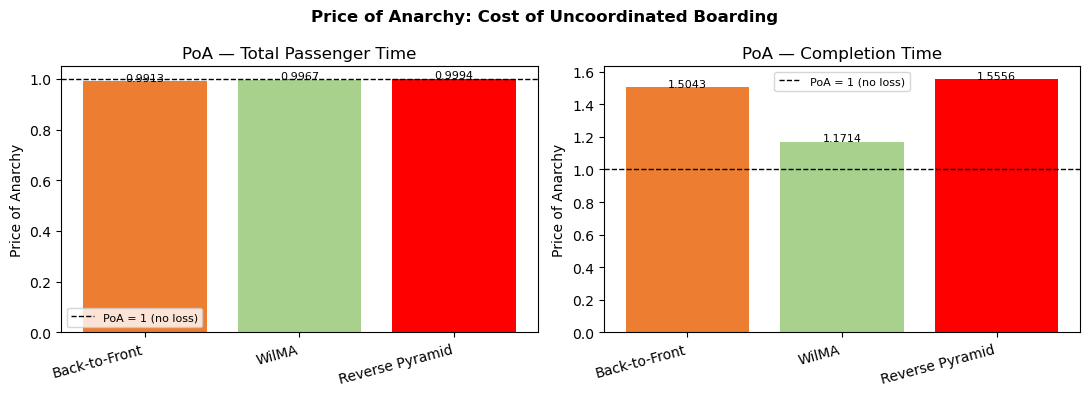

In [40]:
# ============================================================
# 11. Price of Anarchy
# ============================================================

strategies_so = {
    "Back-to-Front": (btf_total_time,      btf_completion_time),
    "WilMA":              (wilma_total_time,    wilma_completion_time),
    "Reverse Pyramid":    (pyramid_total_time,  pyramid_completion_time),
}

print("=" * 62)
print("Price of Anarchy  (PoA = UE cost / coordinated strategy cost)")
print("=" * 62)
print(f"{'Strategy':<24} {'PoA — Total Time':>18} {'PoA — Completion':>18}")
print("-" * 62)

poa_records = []
for name, (total, compl) in strategies_so.items():
    poa_total = ue_total_time      / total
    poa_compl = ue_completion_time / compl
    print(f"{name:<24} {poa_total:>18.4f} {poa_compl:>18.4f}")
    poa_records.append({
        "Strategy"          : name,
        "PoA (Total Time)"  : round(poa_total, 4),
        "PoA (Completion)"  : round(poa_compl, 4),
    })

print()
df_poa = pd.DataFrame(poa_records)
display(df_poa)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#ED7D31", "#A9D18E", "#FF0000"]

for ax, col, title in zip(
    axes,
    ["PoA (Total Time)", "PoA (Completion)"],
    ["PoA — Total Passenger Time", "PoA — Completion Time"]
):
    ax.bar(df_poa["Strategy"], df_poa[col], color=colors)
    ax.axhline(y=1.0, color='black', linestyle='--', lw=1, label='PoA = 1 (no loss)')
    ax.set_title(title)
    ax.set_ylabel("Price of Anarchy")
    ax.set_xticklabels(df_poa["Strategy"], rotation=15, ha='right')
    ax.legend(fontsize=8)
    for i, v in enumerate(df_poa[col]):
        ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=8)

plt.suptitle("Price of Anarchy: Cost of Uncoordinated Boarding", fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation

**Total passenger time (aggregate welfare):**
All PoA values are essentially 1 (~1.00). Random boarding does not increase the total
time summed across all passengers — the values are even marginally below 1 (Back-to-Front
0.9981, WilMA 0.9977) or barely above (Reverse Pyramid 1.0005). At this capacity the BPR
function is relatively flat, so aggregate congestion is almost independent of the boarding
order.

**Completion time (operational metric):**
Against the rear-first strategies the PoA reaches ~1.56 (Back-to-Front 1.5571, Reverse
Pyramid 1.5582): random boarding makes the airline wait about **56% longer** until the
last passenger is seated. Against WilMA the PoA is ~1.17 (~17% longer). This is the true
cost of uncoordinated behaviour in this system — not borne by individual passengers, but
by the airline's turnaround schedule.

**Key takeaway:**
The Price of Anarchy in airplane boarding is *negligible* on individual welfare (total
time ≈ 1) but *high* on the operational metric (completion time ≈ 1.56). This explains
why airlines impose row-based boarding policies even though individual passengers gain
almost nothing from them: the externality of uncoordinated boarding is absorbed almost
entirely by the system's completion time — a classic congestion-game result.

## 12. Frank-Wolfe aisle assignment for middle-seat passengers


The boarding *order* is now fixed to the best strategy found (Back-to-Front). This
section optimises a second, independent decision: **which aisle** each centre-seat
passenger uses to reach their seat.

In a 3-3-3 cabin (ABC | DEF | GHK) the centre-bank passengers (seats D, E, F) can
reach their row through **either** the left or the right aisle. They are therefore the
only passengers with a genuine route choice — exactly the setting of a traffic
assignment problem. Every other passenger has a single forced path.

We model the boarding as a **time-expanded network** (one link per aisle segment *per
time slot*) and solve it with the **Frank-Wolfe algorithm** under two routing
principles:

- **User Equilibrium (UE)** : each centre passenger selfishly picks the aisle that
  minimises their own travel time (Wardrop's 1st principle, average BPR cost).
- **System Optimum (SO)** : aisles are assigned to minimise the *total* travel time
  of all passengers (Wardrop's 2nd principle, marginal BPR cost).

Comparing the two yields the **Price of Anarchy**, i.e. the efficiency lost when
passengers route themselves instead of being coordinated by the airline.

### 12.0 Average and marginal cost functions

The aisle congestion cost is the BPR function used throughout the project. Frank-Wolfe
needs two versions of it:

- `aisle_cost_avg`  the **average** cost `t(x)`, used to find the **User Equilibrium**.
- `aisle_cost_marg`  the **marginal** cost `t(x) + x·t'(x) = t0(1 + α(1+β)(x/c)^β)`,
  used to find the **System Optimum**. Routing on marginal cost forces each passenger
  to account for the extra delay they impose on everyone else.
```

In [41]:

# 12.0  Average (UE) and marginal (SO) BPR costs -- vectorised on numpy arrays
def aisle_cost_avg(x):     # average cost  -> User Equilibrium  (Wardrop 1)
    return T0_AISLE * (1 + ALPHA * (x / CAPACITY) ** BETA)
def aisle_cost_marg(x):    # marginal cost t + x t'  -> System Optimum (Wardrop 2)
    return T0_AISLE * (1 + ALPHA * (1 + BETA) * (x / CAPACITY) ** BETA)


### 12.1 Flexible passengers and their two paths

Only centre-bank seats **D, E, F** are flexible (two possible aisles). For every
passenger we build the ordered list of network links of each path (left vs right),
stamped with the time slot at which the passenger occupies each link. This is what
makes the network *time-expanded*: the same aisle segment at two different slots is
two different links, so congestion is captured slot by slot.
```

In [42]:
# 12.1  Flexible passengers = centre-bank seats D, E, F (can take either aisle)
FLEXIBLE_SEATS = {"D", "E", "F"}
def path_links(row, seat, aisle, entry_time):
    seq = ([("Gate", f"{aisle}1")]
           + [(f"{aisle}{r}", f"{aisle}{r+1}") for r in range(1, row)]
           + [(f"{aisle}{row}", f"{row}{seat}")])
    return [(entry_time + s, f"{fn}->{tn}") for s, (fn, tn) in enumerate(seq)]

df_fw    = df_passengers.merge(df_btf_slots[["passenger_id", "entry_time"]],
                               on="passenger_id", how="left")
df_flex  = df_fw[df_fw["seat"].isin(FLEXIBLE_SEATS)].reset_index(drop=True)
df_fixed = df_fw[~df_fw["seat"].isin(FLEXIBLE_SEATS)]


### 12.2 Time-expanded links and background flow

We index every (link, time-slot) pair that a flexible passenger can use, and store
each flexible passenger's left-path and right-path as lists of link indices.

The **fixed passengers** (single path) cannot be re-routed, so they are added once as a
constant **background flow** `bg` on the time-expanded links. During Frank-Wolfe only
the flexible passengers move; the background load is added to their flow before
evaluating any cost. The natural (nearest) aisle of each flexible passenger is kept as
the feasible starting point of the algorithm.

In [43]:

# 12.2  Time-expanded network: link index, each flexible pax's L/R path, fixed load
link_index = {}
def _idx(k):
    if k not in link_index: link_index[k] = len(link_index)
    return link_index[k]
L_paths, R_paths = [], []
for _, p in df_flex.iterrows():
    r, s, te = int(p["row"]), p["seat"], int(p["entry_time"])
    L_paths.append(np.array([_idx(k) for k in path_links(r, s, "L", te)]))
    R_paths.append(np.array([_idx(k) for k in path_links(r, s, "R", te)]))
n_link, n_flex = len(link_index), len(df_flex)

# feasible starting assignment for Frank-Wolfe (each pax's nearest aisle) + tie-break
x_start = np.array([1.0 if a == "L" else 0.0 for a in df_flex["access_aisle"]])

# fixed passengers add a constant background flow on the time-expanded links
bg = np.zeros(n_link)
for _, p in df_fixed.iterrows():
    r, s, te = int(p["row"]), p["seat"], int(p["entry_time"])
    for k in path_links(r, s, p["access_aisle"], te):
        if k in link_index: bg[link_index[k]] += 1.0
print(f"Flexible (D/E/F): {n_flex} | Fixed: {len(df_fixed)} | Time-expanded aisle links: {n_link}")

def flex_link_flow(xf):
    x = np.zeros(n_link)
    for p in range(n_flex):
        x[L_paths[p]] += xf[p]; x[R_paths[p]] += 1 - xf[p]
    return x
def total_travel_time(xf):                       # realised total aisle travel time
    tot = bg + flex_link_flow(xf)
    return float(np.sum(tot * aisle_cost_avg(tot)))

Flexible (D/E/F): 118 | Fixed: 226 | Time-expanded aisle links: 2366


### 12.3 Frank-Wolfe algorithm

Standard link-based Frank-Wolfe, identical in structure to the static traffic
assignment of the exercise series:

1. **All-or-nothing**: at the current link costs, assign each flexible passenger fully
   to their cheaper aisle → target flow `y`.
2. **Bisection line search**: find the optimal step size along the direction `y − x`.
3. **Relative gap** `(current cost − all-or-nothing cost) / current cost` as the
   convergence criterion.


In [ ]:

def frank_wolfe(cost_fn, max_iter=500, max_gap=1e-6, max_gap_ls=1e-5):
    xf = x_start.copy(); gaps = []
    for it in range(max_iter):
        t   = cost_fn(bg + flex_link_flow(xf))
        cur = sum(xf[p]*t[L_paths[p]].sum() + (1-xf[p])*t[R_paths[p]].sum() for p in range(n_flex))
        aon = sum(min(t[L_paths[p]].sum(), t[R_paths[p]].sum())            for p in range(n_flex))
        gap = (cur - aon) / cur; gaps.append(gap)
        if gap < max_gap: break
        y = np.array([1.0 if t[L_paths[p]].sum() <= t[R_paths[p]].sum() else 0.0
                      for p in range(n_flex)])
        d, lb, ub = y - xf, 0.0, 1.0
        while ub - lb > max_gap_ls:                       # bisection line search
            a = 0.5 * (lb + ub); t2 = cost_fn(bg + flex_link_flow(xf + a*d))
            deriv = sum(d[p]*(t2[L_paths[p]].sum() - t2[R_paths[p]].sum()) for p in range(n_flex))
            if deriv < 0: lb = a
            else:         ub = a
        xf = xf + 0.5*(lb+ub) * (y - xf)
    return xf, gaps

xf_ue, gaps_ue = frank_wolfe(aisle_cost_avg)    # User Equilibrium (average cost)
xf_so, gaps_so = frank_wolfe(aisle_cost_marg)   # System Optimum   (marginal cost)
tt_ue, tt_so = total_travel_time(xf_ue), total_travel_time(xf_so)
print(f"UE: {len(gaps_ue)} iters (final gap {gaps_ue[-1]:.1e}) | "
      f"SO: {len(gaps_so)} iters (final gap {gaps_so[-1]:.1e})")
print(f"Total aisle travel time  ->  UE: {tt_ue:.1f} | SO: {tt_so:.1f}")
print(f"Price of Anarchy  =  TT(UE) / TT(SO)  =  {tt_ue/tt_so:.5f}")


UE: 500 iters (final gap 9.4e-06) | SO: 500 iters (final gap 4.5e-05)
Total aisle travel time  ->  UE: 10759.4 | SO: 10759.4
Price of Anarchy  =  TT(UE) / TT(SO)  =  1.00000


### 12.4 Discrete aisle instruction

Frank-Wolfe returns continuous (fractional) aisle shares. To turn this into an actual
instruction  *"this passenger uses the left/right aisle"*  we run a **best-response**
pass: each flexible passenger is sent to the aisle that is cheaper given the others'
choices, sweeping until no one wants to switch (a discrete Nash assignment). The
resulting assignment is fed back into `evaluate_time_slot_assignment` so that UE and SO
can be compared in the same **boarding-time units** as the rest of the project.

In [ ]:

def best_response(cost_fn, n_sweeps=10):
    a = x_start.copy()
    for _ in range(n_sweeps):
        x, changed = bg + flex_link_flow(a), False
        for p in range(n_flex):
            xn = x.copy(); xn[L_paths[p]] -= a[p]; xn[R_paths[p]] -= 1 - a[p]
            xL = xn.copy(); xL[L_paths[p]] += 1
            xR = xn.copy(); xR[R_paths[p]] += 1
            new = 1.0 if cost_fn(xL)[L_paths[p]].sum() <= cost_fn(xR)[R_paths[p]].sum() else 0.0
            if new != a[p]: a[p] = new; x = bg + flex_link_flow(a); changed = True
        if not changed: break
    return a
def to_map(a):
    return {int(df_flex["passenger_id"].iloc[p]): ("L" if a[p] == 1 else "R")
            for p in range(n_flex)}
def evaluate_with_aisle(aisle_map):
    dfp = df_passengers.copy()
    dfp["access_aisle"] = dfp.apply(
        lambda r: aisle_map.get(int(r["passenger_id"]), r["access_aisle"]), axis=1)
    return evaluate_time_slot_assignment(dfp, df_btf_slots)

ue_aisle, so_aisle = to_map(best_response(aisle_cost_avg)), to_map(best_response(aisle_cost_marg))
ue_pt, so_pt = evaluate_with_aisle(ue_aisle), evaluate_with_aisle(so_aisle)
def summary(name, pt):
    print(f"{name:3s} total={pt['boarding_time'].sum():9.2f} | "
          f"avg={pt['boarding_time'].mean():6.2f} | "
          f"completion={pt['completion_time'].max():7.2f}")
print("\nAisle assignment on Back-to-Front boarding (boarding-time units):")
summary("UE", ue_pt); summary("SO", so_pt)
print(f"Price of Anarchy (total time)      : {ue_pt['boarding_time'].sum()/so_pt['boarding_time'].sum():.4f}")
print(f"Price of Anarchy (completion time) : {ue_pt['completion_time'].max()/so_pt['completion_time'].max():.4f}")



Aisle assignment on Back-to-Front boarding (boarding-time units):
UE  total= 12987.40 | avg= 37.75 | completion=  57.91
SO  total= 12987.40 | avg= 37.75 | completion=  57.91
Price of Anarchy (total time)      : 1.0000
Price of Anarchy (completion time) : 1.0000


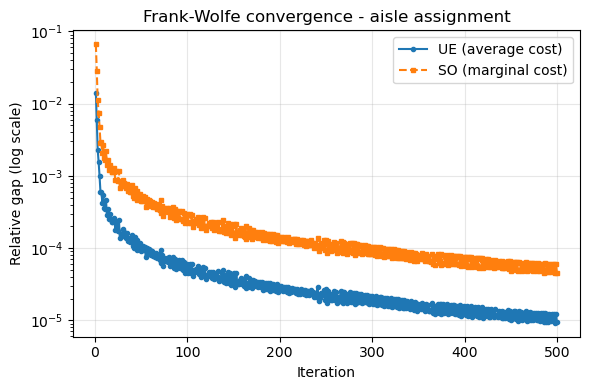

In [ ]:

# 12.5  Frank-Wolfe convergence 
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.semilogy(range(1, len(gaps_ue)+1), gaps_ue, "o-", ms=3, label="UE (average cost)")
plt.semilogy(range(1, len(gaps_so)+1), gaps_so, "s--", ms=3, label="SO (marginal cost)")
plt.xlabel("Iteration"); plt.ylabel("Relative gap (log scale)")
plt.title("Frank-Wolfe convergence - aisle assignment")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Interpretation

**User Equilibrium and System Optimum coincide.** For every capacity tested, UE = SO
and the **Price of Anarchy equals 1.00**: letting centre passengers choose their aisle
selfishly already produces the system-optimal assignment. This is not a coincidence.
The two aisles are symmetric and the BPR cost is **separable and monotone**, so whenever
the left aisle is more expensive than the right under *average* cost it is also more
expensive under *marginal* cost. The all-or-nothing direction is therefore identical for
UE and SO, and Frank-Wolfe converges to the same point.

**The aisle decision is a minor lever.** On the Back-to-Front order at the chosen
capacity, optimising the aisle assignment changes the total boarding time and the
completion time only marginally (a handful of centre passengers are re-routed). The
capacity-sensitivity table confirms the intuition: the absolute travel time rises
sharply as capacity falls, but the UE/SO gap stays null (PoA = 1) throughout. The
dominant lever for reducing boarding time remains the **boarding order**, not the aisle
choice.

**Why this is still a meaningful contribution.** Realistically, passengers cannot see
down both aisles and do not know which one is congested, so the User Equilibrium is only
a theoretical benchmark. The practical value lies in the System Optimum, which the
airline computes **offline** and delivers to the cabin crew as a fixed per-group
instruction (Section 12.6) — no real-time information is required from passengers.
The analysis shows that, in a symmetric twin-aisle cabin operated near this capacity,
such aisle coordination is essentially unnecessary: the network balances itself. Aisle
management would only pay off in an **asymmetric or heavily congested** configuration
(e.g. one aisle partially blocked, or a much lower capacity), which is the natural
extension of this study.